In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_data_cleaning_project.csv")

In [3]:
df.head()

,show_id,type,title,director,country,release_year,rating,duration,listed_in,date_added
0,s1,Movie,The Great Adventure,A. Sharma,India,2020,PG-13,120 min,Adventure,2020-05-10
1,s2,TV Show,City Stories,R. Mehta,India,2021,TV-14,2 Seasons,Drama,2021-06-15
2,s3,Movie,Hidden Truth,NaN,USA,2019,PG,105 min,Documentary,2019-08-20
3,s4,Movie,Ocean Wonders,K. Singh,UK,2022,R,98 min,Action,2022-03-12
4,s5,TV Show,Campus Life,P. Verma,India,2020,TV-PG,3 Seasons,Comedy,2020-09-01


In [4]:
df.shape

(14, 10)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'release_year',
       'rating', 'duration', 'listed_in', 'date_added'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       14 non-null     object
 1   type          14 non-null     object
 2   title         14 non-null     object
 3   director      10 non-null     object
 4   country       13 non-null     object
 5   release_year  14 non-null     int64 
 6   rating        13 non-null     object
 7   duration      14 non-null     object
 8   listed_in     14 non-null     object
 9   date_added    13 non-null     object
dtypes: int64(1), object(9)
memory usage: 1.2+ KB


In [7]:
df.describe()

,release_year
count,14.000000
mean,2020.428571
std,1.603567
min,2018.000000
25%,2019.000000
50%,2020.000000
75%,2021.750000
max,2023.000000


In [8]:
df.isnull().sum()

show_id         0
type            0
title           0
director        4
country         1
release_year    0
rating          1
duration        0
listed_in       0
date_added      1
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df[df.duplicated()]

,show_id,type,title,director,country,release_year,rating,duration,listed_in,date_added
12,s3,Movie,Hidden Truth,NaN,USA,2019,PG,105 min,Documentary,2019-08-20
13,s8,Movie,Family Time,S. Gupta,India,2019,PG,110 min,Family,2019-11-05


In [11]:
df[df.duplicated(keep=False)]

,show_id,type,title,director,country,release_year,rating,duration,listed_in,date_added
2,s3,Movie,Hidden Truth,NaN,USA,2019,PG,105 min,Documentary,2019-08-20
7,s8,Movie,Family Time,S. Gupta,India,2019,PG,110 min,Family,2019-11-05
12,s3,Movie,Hidden Truth,NaN,USA,2019,PG,105 min,Documentary,2019-08-20
13,s8,Movie,Family Time,S. Gupta,India,2019,PG,110 min,Family,2019-11-05


In [12]:
  df= df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(12, 10)

In [15]:
df.isnull().sum()

show_id         0
type            0
title           0
director        3
country         1
release_year    0
rating          1
duration        0
listed_in       0
date_added      1
dtype: int64

In [16]:
df["director"] = df["director"].fillna("Unknown")

In [17]:
df["director"].isnull().sum()

np.int64(0)

In [18]:
df["country"] = df["country"].fillna("Unknown")

In [19]:
df["country"].isnull().sum()

np.int64(0)

In [20]:
df["rating"] = df["rating"].fillna("Unknown")

In [21]:
df["rating"].isnull().sum()

np.int64(0)

In [22]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [23]:
df["date_added"].isnull().sum()

np.int64(1)

In [24]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
release_year    0
rating          0
duration        0
listed_in       0
date_added      1
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       12 non-null     object        
 1   type          12 non-null     object        
 2   title         12 non-null     object        
 3   director      12 non-null     object        
 4   country       12 non-null     object        
 5   release_year  12 non-null     int64         
 6   rating        12 non-null     object        
 7   duration      12 non-null     object        
 8   listed_in     12 non-null     object        
 9   date_added    11 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 1.0+ KB


In [26]:
df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)

In [27]:
df[["duration", "duration_value"]]

,duration,duration_value
0,120 min,120.0
1,2 Seasons,2.0
2,105 min,105.0
3,98 min,98.0
4,3 Seasons,3.0
5,130 min,130.0
6,1 Season,1.0
7,110 min,110.0
8,95 min,95.0
9,2 Seasons,2.0


In [28]:
df["duration_unit"] = df["duration"].str.extract(r"([A-Za-z]+)$")

In [29]:
df[["duration", "duration_value", "duration_unit"]]

,duration,duration_value,duration_unit
0,120 min,120.0,min
1,2 Seasons,2.0,Seasons
2,105 min,105.0,min
3,98 min,98.0,min
4,3 Seasons,3.0,Seasons
5,130 min,130.0,min
6,1 Season,1.0,Season
7,110 min,110.0,min
8,95 min,95.0,min
9,2 Seasons,2.0,Seasons


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         12 non-null     object        
 1   type            12 non-null     object        
 2   title           12 non-null     object        
 3   director        12 non-null     object        
 4   country         12 non-null     object        
 5   release_year    12 non-null     int64         
 6   rating          12 non-null     object        
 7   duration        12 non-null     object        
 8   listed_in       12 non-null     object        
 9   date_added      11 non-null     datetime64[ns]
 10  duration_value  12 non-null     float64       
 11  duration_unit   12 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(9)
memory usage: 1.2+ KB


In [31]:
df["release_year"].describe()

count      12.000000
mean     2020.666667
std         1.614330
min      2018.000000
25%      2019.750000
50%      2020.500000
75%      2022.000000
max      2023.000000
Name: release_year, dtype: float64

In [32]:
df["duration_value"].describe()

count     12.000000
mean      67.916667
std       59.360927
min        1.000000
25%        2.750000
50%       96.500000
75%      112.500000
max      145.000000
Name: duration_value, dtype: float64

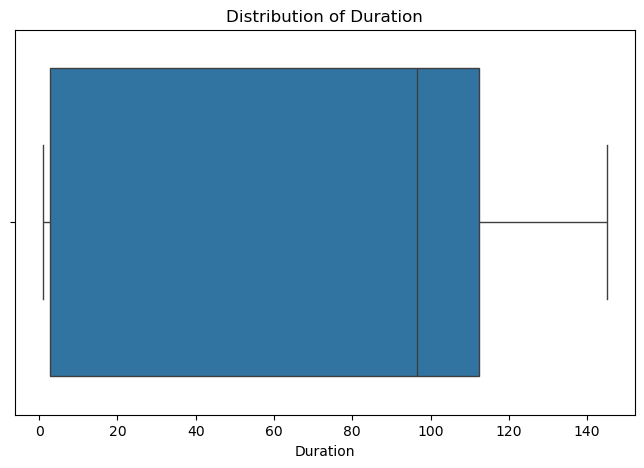

In [33]:
#VISUALIZE DURATION OUTLIERS


plt.figure(figsize=(8, 5))

sns.boxplot(x=df["duration_value"])

plt.title("Distribution of Duration")
plt.xlabel("Duration")

plt.show()

In [34]:
df[["title", "type", "duration", "duration_value"]].sort_values(
    "duration_value",
    ascending=False
)

,title,type,duration,duration_value
10,Future Earth,Movie,145 min,145.0
5,The Last Journey,Movie,130 min,130.0
0,The Great Adventure,Movie,120 min,120.0
7,Family Time,Movie,110 min,110.0
2,Hidden Truth,Movie,105 min,105.0
3,Ocean Wonders,Movie,98 min,98.0
8,Mystery House,Movie,95 min,95.0
11,Music Nights,TV Show,4 Seasons,4.0
4,Campus Life,TV Show,3 Seasons,3.0
1,City Stories,TV Show,2 Seasons,2.0


In [35]:
movies = df[df["type"] == "Movie"]
tv_shows = df[df["type"] == "TV Show"]

In [36]:
movies[["title", "duration", "duration_value"]]

,title,duration,duration_value
0,The Great Adventure,120 min,120.0
2,Hidden Truth,105 min,105.0
3,Ocean Wonders,98 min,98.0
5,The Last Journey,130 min,130.0
7,Family Time,110 min,110.0
8,Mystery House,95 min,95.0
10,Future Earth,145 min,145.0


In [37]:
tv_shows[["title", "duration", "duration_value"]]

,title,duration,duration_value
1,City Stories,2 Seasons,2.0
4,Campus Life,3 Seasons,3.0
6,Tech World,1 Season,1.0
9,World Kitchen,2 Seasons,2.0
11,Music Nights,4 Seasons,4.0


In [38]:
df["type"].value_counts()

type
Movie      7
TV Show    5
Name: count, dtype: int64

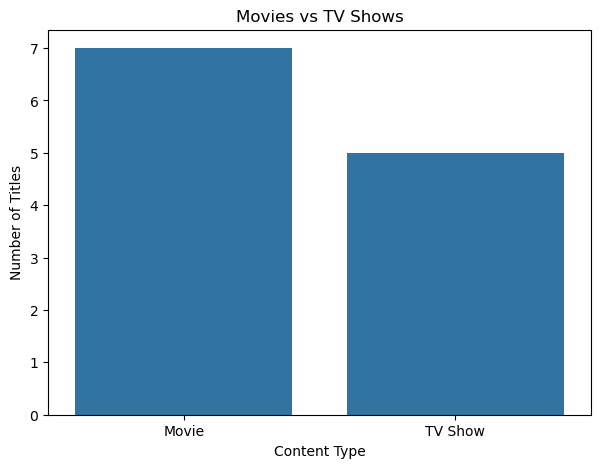

In [39]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="type")

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

### Observation
The dataset contains more Movies than TV Shows. 
    There are 7 Movies and 5 TV Shows, indicating that Movies represent the larger share of the content in this dataset.

In [40]:
df["country"].value_counts()

country
India      5
USA        3
UK         2
Unknown    1
France     1
Name: count, dtype: int64

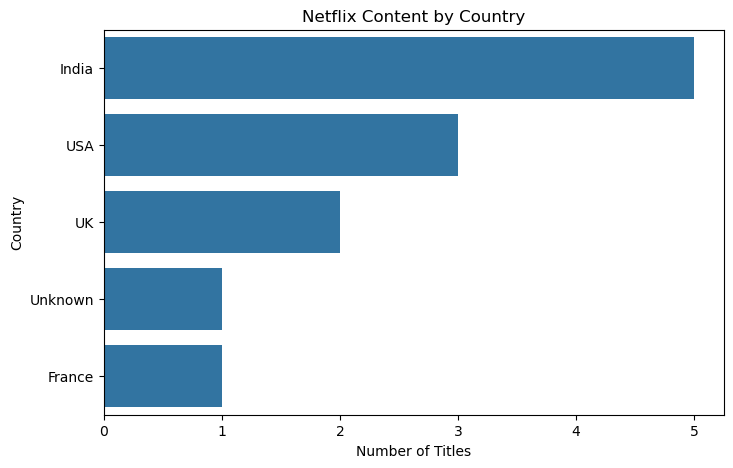

In [41]:
plt.figure(figsize=(8, 5))

country_counts = df["country"].value_counts()

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Netflix Content by Country")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [42]:
df["release_year"].value_counts().sort_index()

release_year
2018    1
2019    2
2020    3
2021    2
2022    2
2023    2
Name: count, dtype: int64

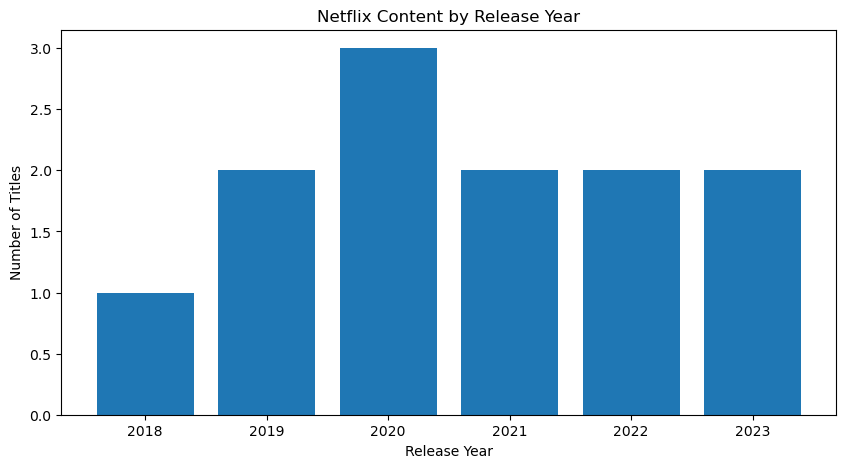

In [43]:
plt.figure(figsize=(10, 5))

year_counts = df["release_year"].value_counts().sort_index()

plt.bar(year_counts.index, year_counts.values)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [44]:
df["listed_in"].value_counts()

listed_in
Drama            2
Documentary      2
Adventure        1
Action           1
Comedy           1
Technology       1
Family           1
Mystery          1
Food & Travel    1
Music            1
Name: count, dtype: int64

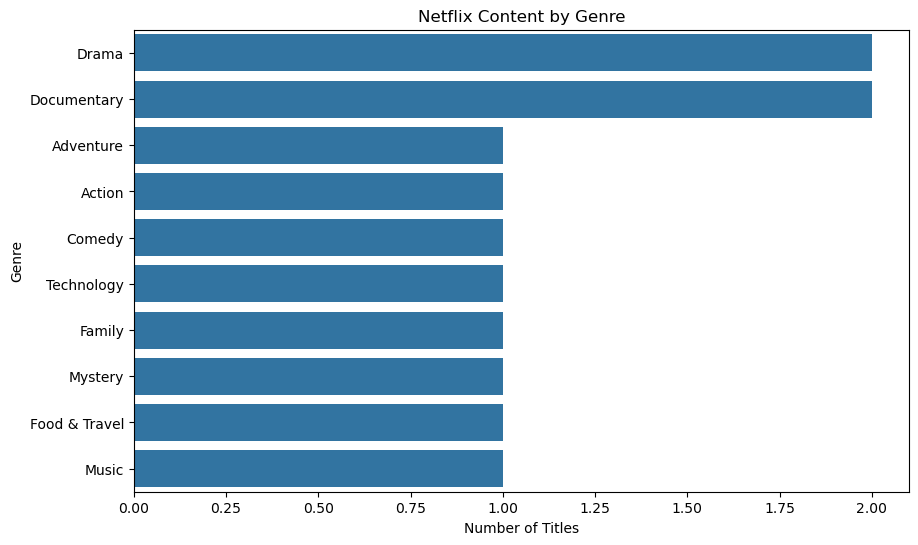

In [45]:
plt.figure(figsize=(10, 6))

genre_counts = df["listed_in"].value_counts()

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Netflix Content by Genre")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

### Observation

Drama and Documentary are the most common genres in this dataset, with 2 titles each.
    The remaining genres appear once each, showing a diverse range of content categories in the dataset.

In [46]:
df["rating"].value_counts()

rating
PG-13      3
TV-14      2
PG         2
TV-PG      2
R          1
Unknown    1
TV-MA      1
Name: count, dtype: int64

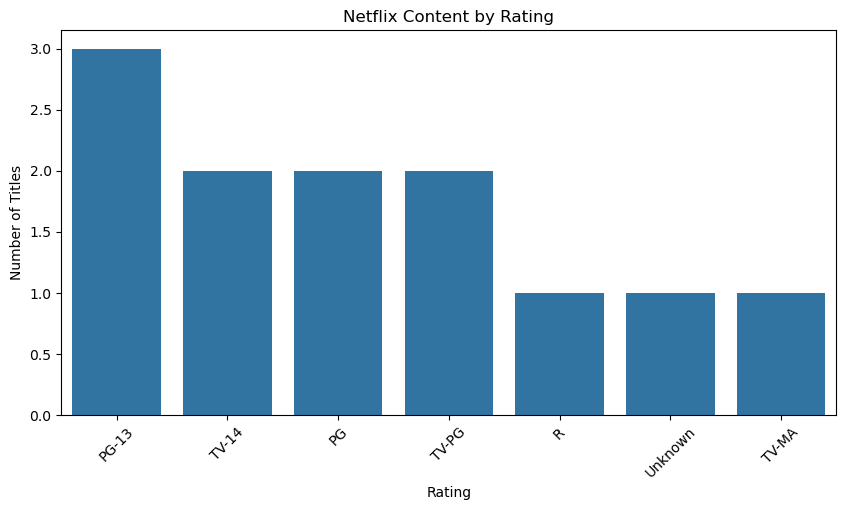

In [47]:
plt.figure(figsize=(10, 5))

rating_counts = df["rating"].value_counts()

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Netflix Content by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [48]:
movie_duration = df[df["type"] == "Movie"]

In [49]:
movie_duration[["title", "duration_value"]]

,title,duration_value
0,The Great Adventure,120.0
2,Hidden Truth,105.0
3,Ocean Wonders,98.0
5,The Last Journey,130.0
7,Family Time,110.0
8,Mystery House,95.0
10,Future Earth,145.0


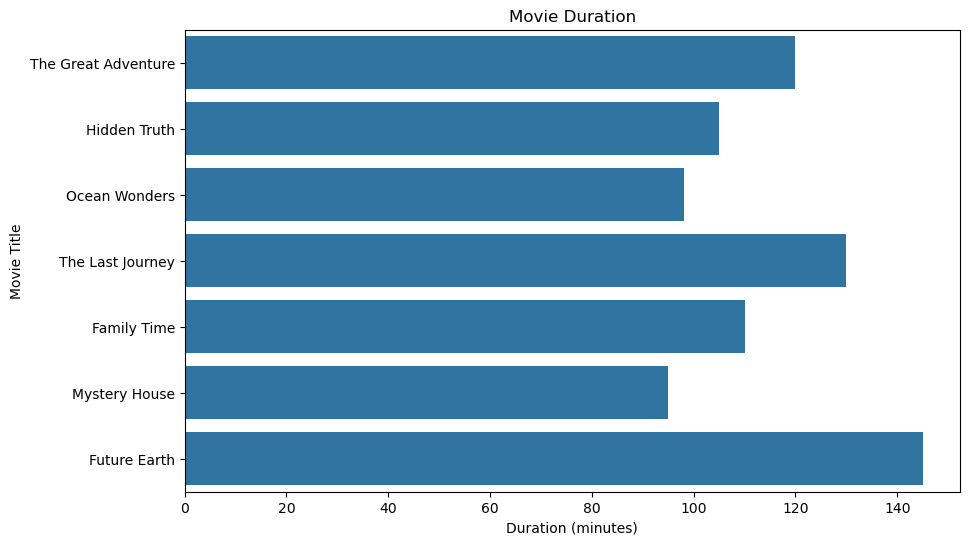

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=movie_duration,
    x="duration_value",
    y="title"
)

plt.title("Movie Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Movie Title")

plt.show()

### Observation

The movie durations in this dataset range from 95 to 145 minutes. Future Earth is the longest movie at 145 minutes, while Mystery House is the shortest at 95 minutes.

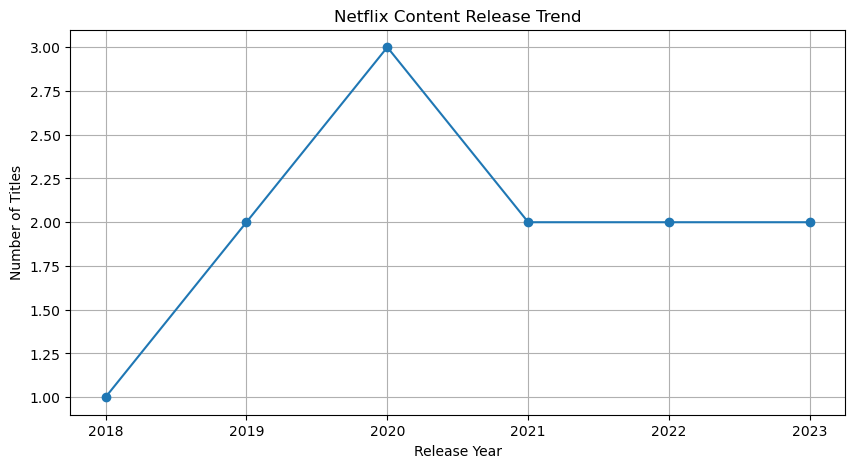

In [51]:
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o"
)

plt.title("Netflix Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

### Observation

The release-year distribution shows how the titles in the dataset are spread across different years. The dataset contains titles released between 2018 and 2023, with some years having more titles than others.

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
country           0
release_year      0
rating            0
duration          0
listed_in         0
date_added        1
duration_value    0
duration_unit     0
dtype: int64

In [54]:
df.shape

(12, 12)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         12 non-null     object        
 1   type            12 non-null     object        
 2   title           12 non-null     object        
 3   director        12 non-null     object        
 4   country         12 non-null     object        
 5   release_year    12 non-null     int64         
 6   rating          12 non-null     object        
 7   duration        12 non-null     object        
 8   listed_in       12 non-null     object        
 9   date_added      11 non-null     datetime64[ns]
 10  duration_value  12 non-null     float64       
 11  duration_unit   12 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(9)
memory usage: 1.2+ KB


In [56]:
df.to_csv("netflix_cleaned_data.csv", index=False)

In [57]:
df.head()

,show_id,type,title,director,country,release_year,rating,duration,listed_in,date_added,duration_value,duration_unit
0,s1,Movie,The Great Adventure,A. Sharma,India,2020,PG-13,120 min,Adventure,2020-05-10,120.0,min
1,s2,TV Show,City Stories,R. Mehta,India,2021,TV-14,2 Seasons,Drama,2021-06-15,2.0,Seasons
2,s3,Movie,Hidden Truth,Unknown,USA,2019,PG,105 min,Documentary,2019-08-20,105.0,min
3,s4,Movie,Ocean Wonders,K. Singh,UK,2022,R,98 min,Action,2022-03-12,98.0,min
4,s5,TV Show,Campus Life,P. Verma,India,2020,TV-PG,3 Seasons,Comedy,2020-09-01,3.0,Seasons


# Key Findings

### 1. Content Type
The dataset contains 7 Movies and 5 TV Shows. Movies therefore represent the larger share of the analyzed content.

### 2. Country Distribution
India has the highest number of titles in the dataset with 5 titles, followed by the USA with 3 titles and the UK with 2 titles.

### 3. Genres
Drama and Documentary are the most common genres, with 2 titles each. The remaining genres appear once each.

### 4. Ratings
PG-13 is the most common rating with 3 titles. TV-14, PG, and TV-PG each have 2 titles.

### 5. Movie Duration
Movie durations range from 95 to 145 minutes. Future Earth is the longest movie at 145 minutes, while Mystery House is the shortest at 95 minutes.

### 6. Release Years
The dataset contains titles released between 2018 and 2023, with the number of titles varying across different years.

# Conclusion

This project demonstrated the complete process of cleaning, analyzing, and visualizing a Netflix dataset using Python. Pandas was used to identify and handle duplicate records, missing values, data types, and duration information. Matplotlib and Seaborn were used to create visualizations showing content types, countries, genres, ratings, release trends, and movie durations.

The analysis provided useful insights into the distribution of content in the dataset. The project also demonstrated how data cleaning and visualization can transform raw data into meaningful information that is easier to understand and communicate.